In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
# sns.set_style('whitegrid')
import sys
import scipy
import os
import glob
import random
import requests
import math
import time

from scipy.interpolate import interp1d
import numpy.polynomial.polynomial as poly
import csv

from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.preprocessing import MinMaxScaler

from datetime import datetime
import matplotlib.colors as colors2
from matplotlib import colormaps as cm
import matplotlib.cm as cmx

import pickle

## custom functions for analysis
import my_functions

#### The EoH performance data can be downloaded from the UK data service
The link is here: https://datacatalogue.ukdataservice.ac.uk/studies/study/9050#documentation

In [2]:
performanceSummaryPath = '../9050_EoH_working_folder/csv/cleaned_1/eoh_summary_for_publication.csv'
perfSummary_df = pd.read_csv(performanceSummaryPath)

In [3]:
includedIDs = perfSummary_df['Property_ID'].iloc[np.where(perfSummary_df['Included_SPF_analysis']==True)[0]].values
print('There are %d included IDs'%len(includedIDs))

There are 545 included IDs


In [4]:
perfSummary_df = perfSummary_df[perfSummary_df['Property_ID'].isin(includedIDs)]

#### The information about the installations is available
The link is here: https://usmart.io/org/esc/discovery/discovery-view-detail/d506e975-cb39-47d7-99e0-e99939a2c4bf

In [5]:
houseMetaPath = '../9050_EoH_working_folder/mrdoc/excel/BEIS Electrification of Heat Project - Property, Design and Installation Information.csv'
meta_df = pd.read_csv(houseMetaPath)

In [6]:
meta_df = meta_df[meta_df['Property_ID'].isin(includedIDs)]
print('we have the meta data for %d houses'%len(meta_df))

we have the meta data for 545 houses


In [7]:
### include only air source heat pumps

# remove the hybrid units
Hybrid_IDs = meta_df.iloc[np.where(meta_df['HP_Installed']=='Hybrid')]['Property_ID'].values
print('Removing %d'%len(Hybrid_IDs) + ' hybrid heat pumps')
meta_df = meta_df[~meta_df['Property_ID'].isin(Hybrid_IDs)]
includedIDs = [x for x in includedIDs if x not in Hybrid_IDs]

# remove the ground source units too since there are so few
GSHP_IDs = meta_df.iloc[np.where(meta_df['HP_Installed']=='GSHP')]['Property_ID'].values
meta_df = meta_df[~meta_df['Property_ID'].isin(GSHP_IDs)]
includedIDs = [x for x in includedIDs if x not in GSHP_IDs]
print('Removing %d'%len(GSHP_IDs) + ' ground source heat pumps')

Removing 95 hybrid heat pumps
Removing 23 ground source heat pumps


In [8]:
# get a list of files for all houses
fileNameList = []
for j in range(4):
    filePath = '../9050_EoH_working_folder/csv/cleaned_'+str(j+1)+'/P*'
    nameList = glob.glob(filePath)
    for entry in nameList:
        fileNameList.append(entry)

In [9]:
print('There are files for %d'%len(fileNameList)+' households')

There are files for 742 households


In [10]:
# create a dict of the fileName and the key (EOHID)
fileNameDict = {}
for entry in fileNameList:
    key = entry.split('ID=')[1].split('.')[0]
    fileNameDict[key] = entry
fileNameDict = {k: v for k, v in fileNameDict.items() if k in includedIDs}

In [11]:
print('There are files for %d'%len(fileNameDict)+' households included in SPF analysis')

There are files for 427 households included in SPF analysis


In [12]:
# for the first house, print some summary stats
EoH_ID = includedIDs[1]
# the filename convention is as follows:
houseSummary_df = perfSummary_df[perfSummary_df['Property_ID']==EoH_ID]
row = houseSummary_df.iloc[0]
count = 0
for col in houseSummary_df.columns:
    print(f"{col}\t{row[col]}")
    count+=1
    if count>15:
        break

Property_ID	EOH0005
Included_SPF_analysis	True
Excluded_SPF_analysis_reason	nan
Whole_dataset_start	21/05/2021 14:00
Whole_dataset_end	28/09/2023 23:58
Whole_dataset_duration_days	860.42
Cleansed_dataset_start	21/05/2021 14:02
Cleansed_dataset_end	28/09/2023 23:56
Cleansed_dataset_duration_days	860.41
Selected_window_start	27/07/2022
Selected_window_end	27/07/2023
Max_quality_score_selected_window	2.0
Mean_quality_score_selected_window	0.001
SPFH2_selected_window	3.476
SPFH3_selected_window	3.476
SPFH4_selected_window	3.405


In [13]:
fileName = fileNameDict[EoH_ID]
print(pd.to_datetime( datetime.strptime(houseSummary_df['Selected_window_start'].iloc[0], "%d/%m/%Y") ))
print(fileName)

2022-07-27 00:00:00
../9050_EoH_working_folder/csv/cleaned_1/Property_ID=EOH0005.csv


In [14]:
# let's just make sure that we can calculate the SPF correctly
df = pd.read_csv(fileName, header=0)

# keep only the data for the selected window
start_TS = pd.to_datetime( datetime.strptime(houseSummary_df['Selected_window_start'].iloc[0], "%d/%m/%Y") )
end_TS = pd.to_datetime( datetime.strptime(houseSummary_df['Selected_window_end'].iloc[0], "%d/%m/%Y") )

# convert the df column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

mask = (df['Timestamp'] >= start_TS) & (df['Timestamp'] <= end_TS)
df = df.loc[mask,:]
df = df.set_index('Timestamp')

SPF_H2, SPF_H3, SPF_H4 = my_functions.get_SPFs(df)

print('SPF_H2 = %.2f' %SPF_H2)
print('SPF_H3 = %.2f' %SPF_H3)
print('SPF_H4 = %.2f' %SPF_H4)
print( 'The heat pump size is %.2f'%meta_df[meta_df['Property_ID']==EoH_ID]['HP_Size_kW'].values[0] )

SPF_H2 = 3.48
SPF_H3 = 3.48
SPF_H4 = 3.41
The heat pump size is 7.00


In [15]:
# # import the prices from the different regions from Octopus for the agile tariff

# PRODUCT = "AGILE-18-02-21"
# TARIFF_PREFIX = "E-1R-AGILE-18-02-21-{}"
# BASE = (
#     f"https://api.octopus.energy/v1/products/{PRODUCT}/"
#     f"electricity-tariffs/{TARIFF_PREFIX}/standard-unit-rates/"
# )

# regions = [chr(c) for c in range(ord("A"), ord("P") + 1) if chr(c) not in {"I", "O"}]

# params0 = {
#     "period_from": "2020-12-01T00:00Z",
#     "period_to": "2023-09-30T23:30Z",
#     "page_size": 250
# }

# def fetch_region_series(region, session=None):
#     s = session or requests.Session()
#     base_url = BASE.format(region)

#     all_results = []
#     url = base_url
#     params = params0.copy()

#     print(f"Fetching region {region}")

#     while url:
#         r = s.get(url, params=params)
#         if r.status_code == 429:
#             retry_after = r.headers.get("Retry-After")
#             wait = int(retry_after) if retry_after and retry_after.isdigit() else 5
#             time.sleep(wait)
#             continue

        
#         r.raise_for_status()
#         data = r.json()

#         all_results.extend(data["results"])

#         url = data["next"]
#         time.sleep(0.2)
#         params = None  # next URL already contains params

#     idx = pd.to_datetime([x["valid_from"] for x in all_results], utc=True)
#     vals = [x["value_inc_vat"] for x in all_results]

#     return pd.Series(vals, index=idx, name=region).sort_index()

# # --- Build DataFrame ---
# with requests.Session() as sess:
#     prices_df = pd.concat(
#         [fetch_region_series(r, session=sess) for r in regions],
#         axis=1
#     ).sort_index()

# print(prices_df.head())


In [16]:
# avg_prices_df = prices_df.mean(axis=1).to_frame(name="avg_price")
# avg_prices_df.to_parquet("average_agile_tariff_UK.parquet")
# del prices_df
avg_prices_df = pd.read_parquet("average_agile_tariff_UK.parquet")

In [18]:
sampled_IDs = random.sample(list(fileNameDict.keys()), 18)
# now debug with only two entries
# for key in list(fileNameDict.keys()):
#     if key not in keySelect:
#         del fileNameDict[key]

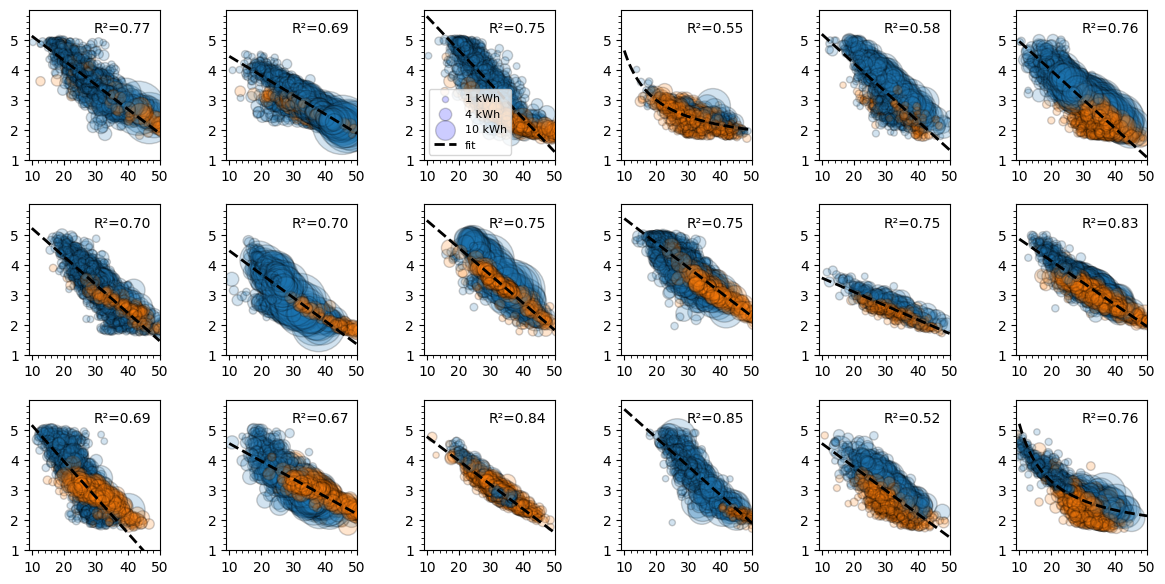

In [20]:
# # for plotting the graphs
# fig, axs = plt.subplots(3,6, figsize = (12,6))
# fig.tight_layout()
# axs = axs.flatten()
# plotCount = 0

# ID_heat_elec = {}
# counter = 0
# for EoH_ID, fileName in fileNameDict.items():

#     houseSummary = perfSummary_df[perfSummary_df['Property_ID']==EoH_ID]
#     df = pd.read_csv(fileName, header=0)

#     ### keep only the data for the selected window
#     start_TS = pd.to_datetime( datetime.strptime(houseSummary['Selected_window_start'].iloc[0], "%d/%m/%Y") )
#     end_TS = pd.to_datetime( datetime.strptime(houseSummary['Selected_window_end'].iloc[0], "%d/%m/%Y") )
#     # convert the df column to datetime
#     df['Timestamp'] = pd.to_datetime(df['Timestamp'])
#     mask = (df['Timestamp'] >= start_TS) & (df['Timestamp'] <= end_TS)
#     df = df.loc[mask,:]
#     df = df.set_index('Timestamp')

#     ### get SPFs
#     SPF_H2, SPF_H3, SPF_H4 = my_functions.get_SPFs(df)
#     ID_heat_elec[EoH_ID] = {}
#     ID_heat_elec[EoH_ID]['SPF_2'] = SPF_H2
#     ID_heat_elec[EoH_ID]['SPF_3'] = SPF_H3
#     ID_heat_elec[EoH_ID]['SPF_4'] = SPF_H4

#     ### get the stuff we want out of the meta data
#     HP_cap = meta_df[meta_df['Property_ID']==EoH_ID]['HP_Size_kW'].values[0]
#     HP_cap_2min = (2*HP_cap)/30 # kWh per 2 min - allow twice the HP rated power
#     ID_heat_elec[EoH_ID]['HP_cap'] = HP_cap
#     ID_heat_elec[EoH_ID]['postcode'] = meta_df[meta_df['Property_ID']==EoH_ID]['Postcode_1']
        
#     # write conditionals for the immersion heater and backup heater  
#     HP = df['Heat_Pump_Energy_Output'].diff()
#     WS = df['Whole_System_Energy_Consumed'].diff()
#     CP = df['Circulation_Pump_Energy_Consumed'].diff()
    
#     IH = df['Immersion_Heater_Energy_Consumed'].diff() if 'Immersion_Heater_Energy_Consumed' in df.columns else 0
#     BU = df['Back-up_Heater_Energy_Consumed'].diff() if 'Back-up_Heater_Energy_Consumed' in df.columns else 0
#     HP_electric = WS - IH - BU 

#     # create a new dataframe that stores internal air, external air, flow, return, heat out and elec in
#     cols_for_temps = [
#         'Internal_Air_Temperature',
#         'External_Air_Temperature',
#         'Heat_Pump_Heating_Flow_Temperature',
#         'Heat_Pump_Return_Temperature',
#         'Hot_Water_Flow_Temperature'
#     ]

#     # adjust the names above to match your actual column names
#     new_df = df[cols_for_temps].copy()
#     new_df['Heat_out']   = HP          # heat output per interval 
#     new_df['Elec_in']    = HP_electric # electrical input per interval
#     # remove first NaN row due to the diffs:
#     new_df = new_df.iloc[1:, :]

#     # remove all the points where there is little electric & see the effect
#     marker = (new_df['Elec_in']<0.01)
#     old_Total_Elec = new_df['Elec_in'].sum()
#     new_df.loc[marker, 'Elec_in'] = 0
#     ID_heat_elec[EoH_ID]['Elec_retained'] = (new_df['Elec_in'].sum()/old_Total_Elec)
    
#     # remove all the points where the heat delivered is unreasonable high & see the effect
#     old_Total_Heat = new_df['Heat_out'].sum()
#     new_df['Heat_out'] = new_df['Heat_out'].clip(upper=HP_cap_2min)
#     ID_heat_elec[EoH_ID]['Heat_retained'] = (new_df['Heat_out'].sum()/old_Total_Heat)

#     # remove the nans from whole system energy consumed 
#     new_df.loc[new_df['Heat_out'].isna(), ['Heat_out', 'Elec_in']] = 0
#     new_df.loc[new_df['Elec_in'].isna(), ['Elec_in']] = 0

#     #################### CREATE A DICTIONATY OF HEAT EVENTS #####################
#     heat_events, sh_accounted_for, hw_accounted_for = my_functions.create_heat_event_dict(new_df, HP_cap_2min)
#     ID_heat_elec[EoH_ID]['Perc_SH_heat_events'] = sh_accounted_for
#     ID_heat_elec[EoH_ID]['Perc_DHW_heat_events'] = hw_accounted_for
    
#     total_heat_by_type = {et: sum(e['heat'] for e in heat_events.values() if e['event_type'] == et)
#     for et in {e['event_type'] for e in heat_events.values()}}

#     total_heat = sum(total_heat_by_type.values())
#     for event_type, heat in total_heat_by_type.items():
#         perc = 100 * heat / total_heat if total_heat > 0 else 0
#         # print(f"{event_type}: {heat:.2f} ({perc:.1f}%)")
    
#     ########################## MAKE A COP FIT BASED ON HEAT EVENTS ##################
#     key_list = heat_events.keys()
#     temperatures = np.array([heat_events[j]['deltaT'] for j in key_list])
#     COPs = np.array([heat_events[j]['COP'] for j in key_list] )
#     heat_values = np.array([heat_events[j]['heat'] for j in key_list])
#     LF_values = np.array([heat_events[j]['LF'] for j in key_list])
#     event_types = [heat_events[j]['event_type'] for j in key_list]

#     if EoH_ID in sampled_IDs:
#         Results = my_functions.fit_cop_models(temperatures, COPs, heat_values, event_types, do_plot=True, ax=axs[plotCount])
#         plotCount = plotCount+1
#     else:
#         Results = my_functions.fit_cop_models(temperatures, COPs, heat_values, event_types)
    
#     ID_heat_elec[EoH_ID]['COP model'] = {}
#     ID_heat_elec[EoH_ID]['COP model']['type'] = Results['best_type']
#     ID_heat_elec[EoH_ID]['COP model']['params'] = Results['best_params']
#     ID_heat_elec[EoH_ID]['COP model']['R2'] = Results['R2_best']

#     ########################## CREATE AN HH DEMAND PROFILE ##################
#     # create an half-hourly demand profile for both heat and hot water
#     # separate the new_df['Heat_out'] into heat and dhw
#     # need to figure out how to fill the missing data for all the columns

#     # split the heat out into space heating and hot water
#     new_df['Heat_out_space_heat'] = 0.0
#     new_df['Heat_out_hot_water'] = 0.0
    
#     # masks
#     sh = new_df['Heat_Pump_Heating_Flow_Temperature'].notna()
#     hw = new_df['Hot_Water_Flow_Temperature'].notna()
    
#     # space heat ONLY when SH is present AND HW is NOT
#     new_df.loc[sh & ~hw, 'Heat_out_space_heat'] = new_df.loc[sh & ~hw, 'Heat_out']
#     # hot water when HW is present
#     new_df.loc[hw, 'Heat_out_hot_water'] = new_df.loc[hw, 'Heat_out']

#     ID_heat_elec[EoH_ID]['Total_HW'] = new_df['Heat_out_hot_water'].sum()
#     ID_heat_elec[EoH_ID]['Total_SH'] = new_df['Heat_out_space_heat'].sum()

#     df_HH = new_df.resample('30min').agg({
#         'External_Air_Temperature': 'mean',
#         'Internal_Air_Temperature': 'mean',
#         'Heat_Pump_Heating_Flow_Temperature': 'mean',
#         'Heat_Pump_Return_Temperature': 'mean',
#         'Hot_Water_Flow_Temperature': 'mean',
#         'Heat_out': 'sum',
#         'Elec_in': 'sum',
#     })

#     ########################## CLEAN AND FILL ##################
#     # When there is no heat delivered, set flow temps to return temp
#     mask = df_HH['Heat_out'] == 0
    
#     df_HH.loc[mask, 'Heat_Pump_Heating_Flow_Temperature'] = (
#         df_HH.loc[mask, 'Heat_Pump_Return_Temperature']
#     )
    
#     df_HH.loc[mask, 'Hot_Water_Flow_Temperature'] = (
#         df_HH.loc[mask, 'Heat_Pump_Return_Temperature']
#     )

#     for column in df_HH.columns:
#        my_functions.fill_missing_data(df_HH, column)
    
#     # now save the hourly data that we need
#     ID_heat_elec[EoH_ID]['HH_data'] = df_HH


# LEGEND_AX_INDEX = 0  # top-right 
# for i, ax in enumerate(axs):
#     if i != LEGEND_AX_INDEX and ax.get_legend() is not None:
#         ax.get_legend().remove()

In [26]:
# with open('ID_heat_elec.pkl', 'wb') as f:
#     pickle.dump(ID_heat_elec, f)

In [46]:
ID_heat_elec['EOH0234']['HH_data'].head()

,External_Air_Temperature,Internal_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Hot_Water_Flow_Temperature,Heat_out,Elec_in
Timestamp,,,,,,,
2022-09-28 00:00:00,9.060000,18.765714,15.955000,15.955000,15.955000,0.0,0.0
2022-09-28 00:30:00,9.214667,18.650000,15.610667,15.610667,15.610667,0.0,0.0
2022-09-28 01:00:00,8.987333,18.556667,15.254000,15.254000,15.254000,0.0,0.0
2022-09-28 01:30:00,8.317333,18.410000,14.914667,14.914667,14.914667,0.0,0.0
2022-09-28 02:00:00,7.902000,18.308000,14.590667,14.590667,14.590667,0.0,0.0


In [47]:
ids = list(ID_heat_elec.keys())

elec_totals = []
heat_totals = []
sh_totals = []
hw_totals = []

for ID in ids:
    d = ID_heat_elec[ID]

    hh = d["HH_data"]  # pandas DataFrame
    elec_totals.append(hh["Elec_in"].sum())
    heat_totals.append(hh["Heat_out"].sum())

    sh_totals.append(d.get("Total_SH", np.nan))
    hw_totals.append(d.get("Total_HW", np.nan))

# Convert to arrays + drop NaNs where relevant
elec_totals = np.asarray(elec_totals, dtype=float)
heat_totals = np.asarray(heat_totals, dtype=float)
sh_totals   = np.asarray(sh_totals, dtype=float)
hw_totals   = np.asarray(hw_totals, dtype=float)

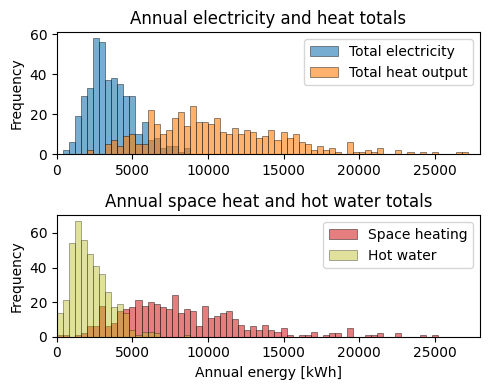

In [48]:
# Histogram settings
bin_width = 400  # kWh
x_min = 0
x_max = 28_000  # kWh (28 MWh)
bins = np.arange(x_min, x_max + bin_width, bin_width)

fig, axs = plt.subplots(2, 1, figsize=(5, 4), tight_layout=True)

# ── Upper plot: total electricity & total heat ────────────────────────────────
axs[0].hist(
    elec_totals,
    bins=bins,
    alpha=0.6,
    label="Total electricity",
    edgecolor="k",
    linewidth=0.5
)

axs[0].hist(
    heat_totals,
    bins=bins,
    alpha=0.6,
    label="Total heat output",
    edgecolor="k",
    linewidth=0.5
)

axs[0].set_xlim(x_min, x_max)
axs[0].set_ylabel("Frequency")
axs[0].set_title("Annual electricity and heat totals")
axs[0].legend()

# ── Lower plot: space heat & hot water ─────────────────────────────────────────
# ── Lower plot: space heat & hot water ─────────────────────────────────────────
axs[1].hist(
    sh_totals,
    bins=bins,
    alpha=0.6,
    label="Space heating",
    color="tab:red",
    edgecolor="k",
    linewidth=0.5
)

axs[1].hist(
    hw_totals,
    bins=bins,
    alpha=0.45,
    label="Hot water",
    color="tab:olive",
    edgecolor="k",
    linewidth=0.5
)

axs[1].set_xlim(x_min, x_max)
axs[1].set_xlabel("Annual energy [kWh]")
axs[1].set_ylabel("Frequency")
axs[1].set_title("Annual space heat and hot water totals")
axs[1].legend()

In [50]:
series_list = []

for ID, d in ID_heat_elec.items():
    hh = d["HH_data"]                      # DataFrame indexed by timestamp
    s = hh["Elec_in"].copy()               # Series with DatetimeIndex

    # Column name: include SH/HW to nearest kWh
    sh = d.get("Total_SH", np.nan)
    hw = d.get("Total_HW", np.nan)

    col_name = f"{ID}_SH={np.round(sh):.0f}kWh_HW={np.round(hw):.0f}kWh"
    s.name = col_name

    series_list.append(s)

# Outer concat aligns on the union of timestamps and fills gaps with NaN
export_df = pd.concat(series_list, axis=1, join="outer").sort_index()

# (Optional) ensure it's hourly / consistent index frequency if you want:
# export_df = export_df.asfreq("H")

export_df.to_csv("Heat_pumps_electricity_in.csv")

In [49]:
# sh = new_df['Heat_Pump_Heating_Flow_Temperature'].notna()
# hw = new_df['Hot_Water_Flow_Temperature'].notna()

# overlap = sh & hw

# if overlap.any():
#     # 1) pick the first overlap timestamp
#     first_ts = new_df.index[overlap][0]
#     print("First overlap at:", first_ts)
#     print("Total overlap points:", int(overlap.sum()))

#     # 2) take a window around it (e.g., +/- 2 hours if 2-min data -> 60 points/hour)
#     # adjust the window size if your timestep is different
#     center_loc = new_df.index.get_loc(first_ts)
#     window = 120  # points on each side (120*2min=4 hours each side if 2-min data)
#     i0 = max(center_loc - window, 0)
#     i1 = min(center_loc + window + 1, len(new_df))

#     snap = new_df.iloc[i0:i1][[
#         'Elec_in',
#         'Heat_out',
#         'Heat_Pump_Heating_Flow_Temperature',
#         'Hot_Water_Flow_Temperature',
#         'Heat_Pump_Return_Temperature',
#         'Internal_Air_Temperature',
#         'External_Air_Temperature',
#     ]].copy()

#     # add an overlap flag so you can see exactly which rows are problematic
#     snap['overlap'] = (snap['Heat_Pump_Heating_Flow_Temperature'].notna() &
#                        snap['Hot_Water_Flow_Temperature'].notna())

#     # 3) print a snapshot (head + the exact overlap rows)
#     print("\n--- Snapshot around first overlap (head) ---")
#     print(snap.head(10))

#     print("\n--- Rows with overlap in this window ---")
#     print(snap[snap['overlap']])

#     # 4) plot both flow temperatures (and optionally return temp + Elec_in)
#     fig, ax = plt.subplots(figsize=(12, 5))
#     ax.plot(snap.index, snap['Heat_Pump_Heating_Flow_Temperature'], label='SH Flow Temp')
#     ax.plot(snap.index, snap['Hot_Water_Flow_Temperature'], label='DHW Flow Temp')
#     ax.plot(snap.index, snap['Heat_Pump_Return_Temperature'], label='Return Temp')

#     # highlight overlap points
#     ax.scatter(snap.index[snap['overlap']],
#                snap.loc[snap['overlap'], 'Heat_Pump_Heating_Flow_Temperature'],
#                marker='x', label='Overlap points (SH)')
#     ax.scatter(snap.index[snap['overlap']],
#                snap.loc[snap['overlap'], 'Hot_Water_Flow_Temperature'],
#                marker='x', label='Overlap points (DHW)')

#     ax.set_title("Flow temperatures around first overlap")
#     ax.set_ylabel("Temperature")
#     ax.legend()
#     ax.grid(True)
#     plt.show()

#     # optional: plot Elec_in on a second axis
#     fig, ax = plt.subplots(figsize=(12, 3))
#     ax.plot(snap.index, snap['Elec_in'], label='Elec_in')
#     ax.set_title("Electrical input around first overlap")
#     ax.set_ylabel("kWh per timestep")
#     ax.grid(True)
#     ax.legend()
#     plt.show()

#     # 5) now raise (or comment this out while debugging)
#     raise ValueError(f"Overlap detected at {first_ts} (and {int(overlap.sum())-1} other points)")
